# 01 — Retrieval Smoke Test

Run 5 representative PubMed QA queries through the hybrid retriever + reranker pipeline  
and manually inspect the top-k chunks for relevance.

This notebook now reuses existing processed data and index artifacts when the older
`src/data/*.py` scripts are not present in the workspace.

Required source modules for the actual smoke test:
```
src/retrieval/hybrid.py
src/retrieval/reranker.py
```

In [11]:
import sys
from pathlib import Path

def resolve_root() -> Path:
    candidates = [
        Path.cwd().resolve(),
        Path.cwd().resolve().parent,
        Path("/teamspace/studios/this_studio"),
    ]
    for candidate in candidates:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the project root containing both src/ and data/.")

ROOT = resolve_root()

for path in [ROOT, ROOT / "src"]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

print("Root:", ROOT)

Root: /teamspace/studios/this_studio


In [12]:
# Preprocess raw PubMed QA data only when the processed artifact is missing.
import subprocess
import sys

preprocess_script = ROOT / "src/data/preprocess.py"
processed_path = ROOT / "data/processed/pubmed_qa_train.jsonl"

if processed_path.exists():
    print("Using existing processed data:", processed_path)
elif preprocess_script.exists():
    subprocess.run(
        [sys.executable, "-m", "src.data.preprocess"],
        cwd=str(ROOT),
        check=True,
    )
    print("Preprocessing completed:", processed_path)
else:
    raise FileNotFoundError(
        "Processed data is missing and src/data/preprocess.py is not present in this workspace."
    )

Using existing processed data: /teamspace/studios/this_studio/data/processed/pubmed_qa_train.jsonl


In [13]:
# Reuse stored index artifacts when available; build only if they are missing.
import subprocess
import sys

build_script = ROOT / "src/data/build_indices.py"
index_files = [
    ROOT / "data/indices/index_store.json",
    ROOT / "data/indices/default__vector_store.json",
    ROOT / "data/indices/bm25/retriever.pkl",
]

if all(path.exists() for path in index_files):
    print("Using existing index artifacts:")
    for path in index_files:
        print(" -", path)
elif build_script.exists():
    subprocess.run(
        [sys.executable, "-m", "src.data.build_indices"],
        cwd=str(ROOT),
        check=True,
    )
    print("Index build completed.")
else:
    raise FileNotFoundError(
        "Index artifacts are missing and src/data/build_indices.py is not present in this workspace."
    )

Using existing index artifacts:
 - /teamspace/studios/this_studio/data/indices/index_store.json
 - /teamspace/studios/this_studio/data/indices/default__vector_store.json
 - /teamspace/studios/this_studio/data/indices/bm25/retriever.pkl


In [14]:
retrieval_pkg = ROOT / "src/retrieval"
if not retrieval_pkg.exists():
    raise ModuleNotFoundError(
        "This notebook expects src/retrieval/, but that package is not present in the current workspace. "
        "Restore the retrieval modules before running the smoke test cells below."
    )

import importlib
import src.retrieval.hybrid as _hybrid_mod
import src.retrieval.reranker as _reranker_mod
importlib.reload(_hybrid_mod)
importlib.reload(_reranker_mod)

from src.retrieval.hybrid import load_hybrid_retriever
from src.retrieval.reranker import build_reranker

retriever = load_hybrid_retriever(similarity_top_k=10)
reranker = build_reranker()  # top_n=3 by default

print("Retriever:", type(retriever).__name__)
print("Reranker :", type(reranker).__name__)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 625.84it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 507.44it/s, Materializing param=classifier.weight]                                    
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Retriever: QueryFusionRetriever
Reranker : SentenceTransformerRerank


In [15]:
SAMPLE_QUERIES = [
    "Does metformin reduce cardiovascular mortality in type 2 diabetes?",
    "Is cognitive behavioural therapy effective for treatment-resistant depression?",
    "What is the role of BRCA1 mutation in breast cancer risk?",
    "Can aspirin prevent colorectal cancer in high-risk patients?",
    "Does sleep deprivation impair immune function?",
]
print(f"{len(SAMPLE_QUERIES)} queries loaded")

5 queries loaded


In [16]:
from llama_index.core.schema import QueryBundle

def retrieve_and_rerank(query: str, verbose: bool = True) -> list:
    """Retrieve candidates with hybrid retriever, then rerank."""
    query_bundle = QueryBundle(query_str=query)

    # Hybrid retrieval (vector + BM25 → RRF)
    candidates = retriever.retrieve(query_bundle)

    # Cross-encoder reranking
    reranked = reranker.postprocess_nodes(candidates, query_bundle=query_bundle)

    if verbose:
        print(f"\nQuery  : {query}")
        print(f"Candidates before rerank : {len(candidates)}")
        print(f"Candidates after  rerank : {len(reranked)}")

    return reranked

In [7]:
import textwrap

results: dict[str, list] = {}

for query in SAMPLE_QUERIES:
    results[query] = retrieve_and_rerank(query)

print("\nAll queries processed.")


Query  : Does metformin reduce cardiovascular mortality in type 2 diabetes?
Candidates before rerank : 10
Candidates after  rerank : 3

Query  : Is cognitive behavioural therapy effective for treatment-resistant depression?
Candidates before rerank : 10
Candidates after  rerank : 3

Query  : What is the role of BRCA1 mutation in breast cancer risk?
Candidates before rerank : 10
Candidates after  rerank : 3

Query  : Can aspirin prevent colorectal cancer in high-risk patients?
Candidates before rerank : 10
Candidates after  rerank : 3

Query  : Does sleep deprivation impair immune function?
Candidates before rerank : 10
Candidates after  rerank : 3

All queries processed.


In [17]:
# ── Pretty-print top chunks for manual relevance inspection ──────────────
WRAP = 100

for query, nodes in results.items():
    print("=" * WRAP)
    print(f"QUERY: {query}")
    print("=" * WRAP)
    for rank, node in enumerate(nodes, start=1):
        score  = getattr(node, "score", None)
        meta   = node.metadata
        text   = textwrap.fill(node.get_content(), width=WRAP)
        print(f"\n  [{rank}] score={score:.4f}  pubmed_id={meta.get('pubmed_id')}")
        print(f"       decision={meta.get('final_decision')}")
        print(f"       question={meta.get('question')[:120]}")
        print(f"  {'-' * (WRAP - 2)}")
        for line in text.splitlines():
            print(f"  {line}")
    print()

QUERY: Does metformin reduce cardiovascular mortality in type 2 diabetes?

  [1] score=1.1430  pubmed_id=15125825
       decision=yes
       question=Starting insulin in type 2 diabetes: continue oral hypoglycemic agents?
  --------------------------------------------------------------------------------------------------
  Fear of self-injecting and self-testing did not differ.'], 'labels': ['OBJECTIVE', 'STUDY DESIGN',
  'POPULATION', 'OUTCOMES MEASURED', 'RESULTS'], 'meshes': ['Analysis of Variance', 'Diabetes
  Mellitus, Type 2', 'Drug Therapy, Combination', 'Female', 'Glycated Hemoglobin A', 'Humans',
  'Hypoglycemic Agents', 'Insulin', 'Insulin, Isophane', 'Male', 'Metformin', 'Middle Aged',
  'Sulfonylurea Compounds'], 'reasoning_required_pred': ['y', 'e', 's'], 'reasoning_free_pred': ['y',
  'e', 's']}

  [2] score=1.0018  pubmed_id=15125825
       decision=yes
       question=Starting insulin in type 2 diabetes: continue oral hypoglycemic agents?
  -----------------------------

In [18]:
# ── Summary table ────────────────────────────────────────────────────────
import pandas as pd

rows = []
for query, nodes in results.items():
    for rank, node in enumerate(nodes, start=1):
        rows.append({
            "query"          : query[:60],
            "rank"           : rank,
            "score"          : round(getattr(node, "score", 0.0), 4),
            "pubmed_id"      : node.metadata.get("pubmed_id"),
            "final_decision" : node.metadata.get("final_decision"),
            "chunk_preview"  : node.get_content()[:120].replace("\n", " "),
        })

df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 120)
df

,query,rank,score,pubmed_id,final_decision,chunk_preview
0,Does metformin reduce cardiovascular mortality in type 2 dia,1,1.1430,15125825,yes,"Fear of self-injecting and self-testing did not differ.'], 'labels': ['OBJECTIVE', 'STUDY DESIGN', 'POPULATION', 'OU..."
1,Does metformin reduce cardiovascular mortality in type 2 dia,2,1.0018,15125825,yes,"', 'HbA1c improved from 8.3% to 7.6% in the IC group, and from 8.8% to 7.6% in the IM group (P=NS). The IC group had..."
2,Does metformin reduce cardiovascular mortality in type 2 dia,3,0.7170,15125825,yes,{'contexts': ['To evaluate the effects of insulin 30/70 twice daily or bedtime isophane (NPH) insulin plus continued...
3,Is cognitive behavioural therapy effective for treatment-res,1,-2.2989,26485091,no,{'contexts': ['Several atypical antipsychotics (AAPs) are used as second-line agents for treatment resistant depress...
4,Is cognitive behavioural therapy effective for treatment-res,2,-5.6563,26485091,no,AAPs resulted in higher mean adjusted pharmacy costs and higher mean adjusted total mental health-related costs. Mea...
5,Is cognitive behavioural therapy effective for treatment-res,3,-6.1765,22303473,no,{'contexts': ['Family caregivers of dementia patients are at increased risk of developing depression or anxiety. A m...
6,What is the role of BRCA1 mutation in breast cancer risk?,1,2.8390,25274085,no,{'contexts': ['Several single nucleotide polymorphisms (SNPs) at different loci have been associated with breast can...
7,What is the role of BRCA1 mutation in breast cancer risk?,2,0.6866,25274085,no,""", '548 female BRCA1 mutation carriers and 523 BRCA2 carriers were identified from the database. Median Kaplan-Meier..."
8,What is the role of BRCA1 mutation in breast cancer risk?,3,-1.7193,22301406,yes,{'contexts': ['CYP2D6 is an important cytochrome P450 enzyme. These enzymes catalyse the oxidative biotransformation...
9,Can aspirin prevent colorectal cancer in high-risk patients?,1,-2.2327,16909975,yes,{'contexts': ['Dryness of the mouth is one of the most distressing chronic toxicities of radiation therapy in head a...


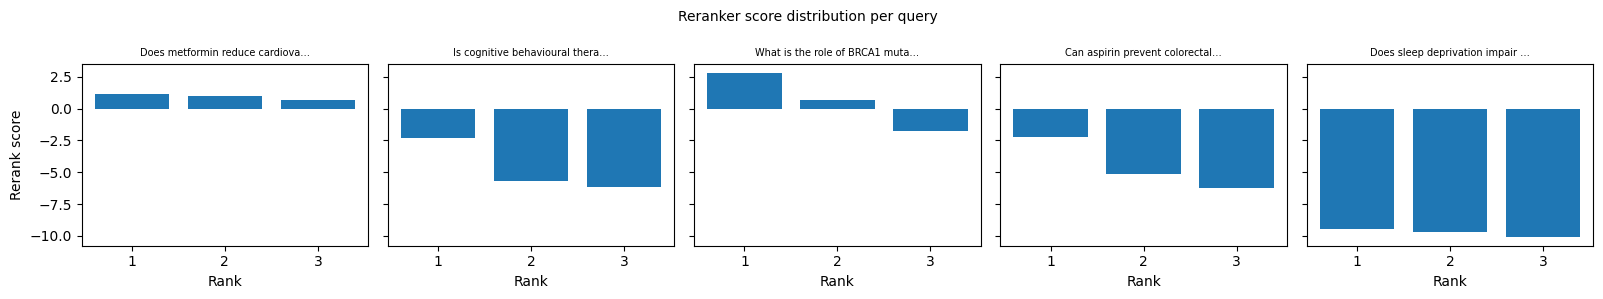

: 

In [ ]:
# ── Quick score distribution per query ───────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(SAMPLE_QUERIES), figsize=(16, 3), sharey=True)

for ax, query in zip(axes, SAMPLE_QUERIES):
    nodes  = results[query]
    scores = [getattr(n, "score", 0.0) for n in nodes]
    ranks  = list(range(1, len(scores) + 1))
    ax.bar(ranks, scores)
    ax.set_title(query[:30] + "…", fontsize=7)
    ax.set_xlabel("Rank")

axes[0].set_ylabel("Rerank score")
plt.suptitle("Reranker score distribution per query", fontsize=10)
plt.tight_layout()
plt.show()